In [ ]:
!pip install category_encoders
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.1 MB/s eta 0:00:00


In [ ]:
# Get ready to train on ML algorithms
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from category_encoders import CountEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
import tensorflow as tf
import keras
from keras import layers

In [ ]:
from sqlalchemy import create_engine
import pandas as pd
import os
import psycopg2
from tqdm.auto import trange
from google.colab import drive
from datetime import datetime
import numpy as np
import joblib

In [ ]:
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/Colab Notebooks/GSMLS')

In [ ]:
tax_engine = create_engine(f"postgresql+psycopg2://postgres:pw@hostname:5433/nj_tax_assessor")

In [ ]:
pd.set_option('display.max_columns', 999)

# Load the data from PostgreSQL

In [ ]:
query = f"SELECT * FROM gsmls_imputed_data LIMIT 1;"
test_data = pd.read_sql_query(query, tax_engine)

In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Columns: 151 entries, mlsnum to year_built
dtypes: bool(102), datetime64[ns](2), float64(23), int64(10), object(14)
memory usage: 626.0+ bytes


In [ ]:
query = f"SELECT * FROM cleaned_data_for_dnn;"
cleaned_data = pd.read_sql_query(query, tax_engine)

In [ ]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555710 entries, 0 to 555709
Columns: 152 entries, STATUS_SHORT to assessment_zscore
dtypes: float64(43), int64(106), object(3)
memory usage: 644.4+ MB


In [ ]:
cleaned_data.head()

,STATUS_SHORT,ADDRESS,LATITUDE,LONGITUDE,DAYSONMARKET,dom_zscore,MORTGAGE_RATE,ORIGLISTPRICE,LISTPRICE,list_price_zscore,property_valuation,assess_to_lp_zscore,list_to_sales_price_zscore,OLP/LP%,SALESPRICE,sales_rate,SQFTAPPROX,sqft_zscore,YEARBUILT,year_built_zscore,SP/LP%,INVESTMENT_SALE,AGE_OF_PROPERTY,age_of_property_zscore,POTENTIAL_INVESTMENT,DISTRESSED_SALE,SHORT_SALE,BANK_OWNED,ROOMS,rooms_zscore,BEDS,beds_zscore,BATHSTOTAL,baths_zscore,LOTSIZE (SQFT),lot_size_zscore,ASSESSAMOUNTBLDG,ASSESSAMOUNTLAND,ASSESSTOTAL,TAXAMOUNT,tax_zscore,SUBPROPTYPE_SFH,STYLEPRIMARY_SHORT,MONTH,YEAR,EASEMENT_SHORT,GARAGECAP,garages_zscore,FIREPLACES,fireplace_zscore,POOL_SHORT,APPFEE,app_fee_zscore,ASSOCFEE,assoc_fee_zscore,WOOD_FLOORS,MARBLE_FLOORS,TILE_FLOORS,CARPET_FLOORS,VINYL_FLOORS,LAMINATE_FLOORS,STONE_FLOORS,PARQUET_FLOORS,OFF_STREET_PKNG,1_CAR_WIDE,2_CAR_WIDE,WINDOW_AC,CENTRAL_AC,1_UNIT_AC,2_UNITS_AC,3_UNITS_AC,WALL_UNIT_AC,CEILFAN_AC,DUCTLESS_AC,MULTIZONE_AC,HEAT_SRC_NATGAS,HEAT_SRC_ELECTRIC,HEAT_SRC_OILABV,HEAT_SRC_OILBEL,HEAT_SRC_SOLAR,BASEDESC_BILCOSTY,BASEDESC_FINISHED,BASEDESC_FINPART,BASEDESC_FRNCHDRN,BASEDESC_FULL,BASEDESC_PARTIAL,BASEDESC_SLAB,BASEDESC_UNFINISH,BASEDESC_WALKOUT,BASEDESC_NONE,EXTERIOR_SHORT_DECK,EXTERIOR_ENCLPRCH,EXTERIOR_FENCPRIV,EXTERIOR_FENCVNYL,EXTERIOR_FENCWOOD,EXTERIOR_GAZEBO,EXTERIOR_HOTTUB,EXTERIOR_METALFNC,EXTERIOR_OPENPRCH,EXTERIOR_OUTDRKIT,EXTERIOR_PATIO,EXTERIOR_PERGOLA,EXTERIOR_SPRINKLR,EXTERIOR_STORAGE,EXTERIOR_WORKSHOP,ROOF_ASPHSHNG,ROOF_COMPSHNG,ROOF_FLAT,SIDING_ALUMINUM,SIDING_BRICK,SIDING_CEDARSID,SIDING_CLAPBRD,SIDING_COMPSHNG,SIDING_COMPSIDE,SIDING_CONCBRD,SIDING_METAL,SIDING_STONE,SIDING_STUCCO,SIDING_VERTICAL,SIDING_VINYL,SIDING_WOOD,SIDING_WOODSHNG,HEATSYSTEM_1UNIT,HEATSYSTEMT_2UNITS,HEATSYSTEM_3UNITS,HEATSYSTEM_4UNITS,HEATSYSTEM_BSBDCAST,HEATSYSTEM_BSBDELEC,HEATSYSTEM_BSBDHOTW,HEATSYSTEM_FORCEDHA,HEATSYSTEM_MULTIZON,HEATSYSTEM_RDNTHOTW,HEATSYSTEM_RDTRHOTW,HEATSYSTEM_RDTRSTM,HEATSYSTEM_REGISTER,SEWER_ASSOCTN,SEWER_PUBLAVAL,SEWER_PUBLIC,SEWER_SEPTIC,WATER_ASSOCTN,WATER_PUBLIC,WATER_PRIVATE,WATER_WELL,WATER_WATRXTRA,UTILITIES_ALLUNDER,UTILITIES_ELECTRIC,UTILITIES_GASNATUR,UTILITIES_GASINSTR,UTILITIES_GASPROPN,lotsize_sqft,assess_to_lp_ratio,assessment_zscore
0,SD,1012 Irving Avenue,40.645253,-74.329194,77.0,0.173583,7.45,229000.0,229000,-0.619153,0,-0.348845,-0.549172,0.0,218000.0,1.0,2071.0,-0.512736,1900.0,-1.617847,-5.0,0,96.0,1.617847,0,0,0,0,6.0,-1.127511,3.0,-0.788173,1.0,-1.233219,5000.00,-0.613164,62400.0,52500.0,114900.0,4205.0,-1.018464,1,Colonial,1,1996,0,0.0,-2.250670,1.0,0.116570,0,0.0,NaN,0.0,-0.180028,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,5009.4000,0.501747,-1.027510
1,SD,717 Summit Avenue,40.643058,-74.340963,103.0,0.600182,7.41,187500.0,187500,-0.902599,0,-0.287032,-0.860084,0.0,182000.0,1.0,1620.0,-0.943250,1890.0,-1.971652,-3.0,0,106.0,1.971652,0,0,0,0,6.0,-1.127511,3.0,-0.788173,1.1,-1.103205,5775.00,-0.553289,56000.0,41100.0,97100.0,3553.0,-1.298044,1,Colonial,1,1996,0,0.0,-2.250670,0.0,-1.534837,0,0.0,NaN,0.0,-0.180028,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,5793.4800,0.517867,-1.313691
2,SD,112 Jefferson Avenue,40.660902,-74.338743,121.0,0.895520,7.60,235000.0,235000,-0.578173,0,0.341198,-0.504221,0.0,220000.0,1.0,2181.0,-0.407733,1950.0,0.151182,-6.0,0,46.0,-0.151182,0,0,0,0,7.0,-0.478858,4.0,0.250504,2.0,0.066919,8102.16,-0.373499,66800.0,93400.0,160200.0,5687.0,-0.382978,1,CapeCod,1,1996,0,1.0,-0.707872,1.0,0.116570,0,0.0,NaN,0.0,-0.180028,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,8102.1600,0.681702,-0.299194
3,SD,307 Hazel S

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
# Properties with extremely low SP/LP ratios are either errors or fixer upper homes. I'll distinguish how to label them later. For now I'll remove them
# I'll have a threshold of > -50 and < 100 SP/LP%. I'll factor in other's on the next version of the model
outlier_max = cleaned_data[(cleaned_data['SP/LP%'] > 100) | (cleaned_data['SP/LP%'] < -50) & (cleaned_data['STATUS_SHORT'] == 'SD')].index

In [ ]:
cleaned_data.drop(outlier_max, inplace=True)

In [ ]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 555299 entries, 0 to 555709
Columns: 152 entries, STATUS_SHORT to assessment_zscore
dtypes: float64(43), int64(106), object(3)
memory usage: 648.2+ MB


# Make a list of all Boolean columns. Will be removed when time to train DNN

In [ ]:
old_boolean_columns = [i for i in test_data.columns if test_data[i].dtype == 'bool']

In [ ]:
old_boolean_columns

['investment_sale',
 'potential_investment',
 'distressed_sale',
 'short_sale',
 'bank_owned',
 'subproptype_sfh',
 'easement_short',
 'pool_short',
 'wood_floors',
 'marble_floors',
 'tile_floors',
 'carpet_floors',
 'vinyl_floors',
 'laminate_floors',
 'stone_floors',
 'parquet_floors',
 'off_street_pkng',
 'one_car_wide',
 'two_car_wide',
 'window_ac',
 'central_ac',
 'one_unit_ac',
 'two_units_ac',
 'three_units_ac',
 'wall_unit_ac',
 'ceilfan_ac',
 'ductless_ac',
 'multizone_ac',
 'heat_src_natgas',
 'heat_src_electric',
 'heat_src_oilabv',
 'heat_src_oilbel',
 'heat_src_solar',
 'basedesc_bilcosty',
 'basedesc_finished',
 'basedesc_finpart',
 'basedesc_frnchdrn',
 'basedesc_full',
 'basedesc_partial',
 'basedesc_slab',
 'basedesc_unfinish',
 'basedesc_walkout',
 'basedesc_none',
 'exterior_short_deck',
 'exterior_enclprch',
 'exterior_fencpriv',
 'exterior_fencvnyl',
 'exterior_fencwood',
 'exterior_gazebo',
 'exterior_hottub',
 'exterior_metalfnc',
 'exterior_openprch',
 'exteri

# List of attributes which will receive Yeo-Johnson and MaxAbsScaler

In [ ]:
from sklearn.preprocessing import PowerTransformer
from scipy.stats import skew as sci_skew

target_col = ['DAYSONMARKET', 'dom_zscore', 'LISTPRICE', 'list_price_zscore', 'list_to_sales_price_zscore',
              'OLP/LP%', 'SALESPRICE', 'ROOMS', 'rooms_zscore', 'SQFTAPPROX', 'sqft_zscore',
              'LOTSIZE (SQFT)', 'lot_size_zscore', 'BEDS', 'beds_zscore', 'BATHSTOTAL', 'baths_zscore',
              'ASSESSTOTAL', 'assessment_zscore', 'TAXAMOUNT', 'tax_zscore',
              'YEARBUILT', 'year_built_zscore', 'GARAGECAP', 'garages_zscore', 'FIREPLACES', 'fireplace_zscore',
              'sales_rate', 'AGE_OF_PROPERTY', 'MONTH', 'YEAR', 'MORTGAGE_RATE', 'LONGITUDE', 'LATITUDE',
              'assess_to_lp_ratio', 'assess_to_lp_zscore']

trans_dict = {
    'col': [],
    'reg_skew': [],
    'Yeo-Johnson_skew': [],
    'Power_Transform': [],
    'Max_Abs_Scaled': []
}

power_transform_cols = []
max_abs_cols = []
target_col.append('property_valuation')

pt = PowerTransformer(method='yeo-johnson')

for col in target_col:
  if 'zscore' not in col:
    trans_dict['col'].append(col)
    skew = cleaned_data[col].skew()
    min_val = cleaned_data[col].min()
    max_val = cleaned_data[col].max()
    trans_dict['reg_skew'].append(skew)
    data = pt.fit_transform(cleaned_data[col].values.reshape(-1,1))

    if skew < -0.8 or skew > 0.8:
      power_transform_cols.append(col)
      trans_dict['Yeo-Johnson_skew'].append(sci_skew(data)[0])
      trans_dict['Power_Transform'].append(True)
    else:
      trans_dict['Yeo-Johnson_skew'].append(skew)
      trans_dict['Power_Transform'].append(False)

    max_abs_cols.append(col)
    trans_dict['Max_Abs_Scaled'].append(True)

trans_df = pd.DataFrame(trans_dict)
trans_df.set_index('col', inplace=True)

In [ ]:
trans_df

,reg_skew,Yeo-Johnson_skew,Power_Transform,Max_Abs_Scaled
col,,,,
DAYSONMARKET,1.747666,-0.069048,True,True
LISTPRICE,2.357969,0.013575,True,True
OLP/LP%,-2.326878,1.796424,True,True
SALESPRICE,1.702954,-0.712737,True,True
ROOMS,0.809581,0.001518,True,True
SQFTAPPROX,1.572142,0.001173,True,True
LOTSIZE (SQFT),62.402672,-0.350939,True,True
BEDS,0.316526,0.316526,False,True
BATHSTOTAL,1.113251,0.023569,True,True


In [ ]:
print(f'Power Transform Columns: {power_transform_cols}')
print(f'Min Max Columns: {max_abs_cols}')

Power Transform Columns: ['DAYSONMARKET', 'LISTPRICE', 'OLP/LP%', 'SALESPRICE', 'ROOMS', 'SQFTAPPROX', 'LOTSIZE (SQFT)', 'BATHSTOTAL', 'ASSESSTOTAL', 'TAXAMOUNT', 'YEARBUILT', 'FIREPLACES', 'AGE_OF_PROPERTY', 'assess_to_lp_ratio', 'property_valuation']
Min Max Columns: ['DAYSONMARKET', 'LISTPRICE', 'OLP/LP%', 'SALESPRICE', 'ROOMS', 'SQFTAPPROX', 'LOTSIZE (SQFT)', 'BEDS', 'BATHSTOTAL', 'ASSESSTOTAL', 'TAXAMOUNT', 'YEARBUILT', 'GARAGECAP', 'FIREPLACES', 'sales_rate', 'AGE_OF_PROPERTY', 'MONTH', 'YEAR', 'MORTGAGE_RATE', 'LONGITUDE', 'LATITUDE', 'assess_to_lp_ratio', 'property_valuation']


In [ ]:
sold_count = cleaned_data[cleaned_data['STATUS_SHORT'] == 'SD']['STATUS_SHORT'].count()
exp_count = cleaned_data[cleaned_data['STATUS_SHORT'] == 'EXP']['STATUS_SHORT'].count()

class_weights = {
    1: len(cleaned_data) / (2 * sold_count),
    0: len(cleaned_data) / (2 * exp_count)
}

print(class_weights)

{1: np.float64(0.71378862666461), 0: np.float64(1.6693793252725184)}


# Train-test-split the data

### Import all transformation and pipeline packages as well as sci-learn models for later usage to create baseline models

In [ ]:
# Add POTENTIAL_INVESTMENT & DISTRESSED_SALE back onced cleaned
gsmls_data = cleaned_data.drop(columns=['ORIGLISTPRICE', 'ASSESSAMOUNTBLDG', 'ASSESSAMOUNTLAND', 'APPFEE', 'ASSOCFEE', 'POTENTIAL_INVESTMENT', 'DISTRESSED_SALE', 'SP/LP%'])
gsmls_data = cleaned_data.drop(columns=[i for i in gsmls_data.columns if 'zscore' in i])

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import AdaBoostRegressor, AdaBoostClassifier

In [ ]:
# Need to train a NLTK Sentiment Analysis for 'LISTING_REMARKS' column
# This is time series data, I need to split the data according to timeframe. As currently stands, I have a data leak
min_year = gsmls_data['YEAR'].min()
max_year = gsmls_data['YEAR'].max()
training_data, val_data, test_data = gsmls_data[gsmls_data['YEAR'] < max_year - 1], gsmls_data[gsmls_data['YEAR'] == max_year - 1], gsmls_data[gsmls_data['YEAR'] == max_year]

In [ ]:
y_train, y_val, y_test = training_data[['SALESPRICE', 'STATUS_SHORT']], val_data[['SALESPRICE', 'STATUS_SHORT']], test_data[['SALESPRICE', 'STATUS_SHORT']]
x_train, x_val, x_test = training_data.drop(columns=['SALESPRICE', 'STATUS_SHORT', 'ADDRESS']), val_data.drop(columns=['SALESPRICE', 'STATUS_SHORT', 'ADDRESS']), test_data.drop(columns=['SALESPRICE', 'STATUS_SHORT', 'ADDRESS'])

In [ ]:
print(f'X_train Shape: {x_train.shape}')
print(f'Y_train Shape: {y_train.shape}')

X_train Shape: (536317, 132)
Y_train Shape: (536317, 2)


In [ ]:
print(f'X_val Shape: {x_val.shape}')
print(f'Y_val Shape: {y_val.shape}')

X_val Shape: (13600, 132)
Y_val Shape: (13600, 2)


In [ ]:
print(f'X_test Shape: {x_test.shape}')
print(f'Y_test Shape: {y_test.shape}')

X_test Shape: (5382, 132)
Y_test Shape: (5382, 2)


# Prepare the transformation pipeline

In [ ]:
boolean_columns = [i for i in old_boolean_columns if i not in ['POTENTIAL_INVESTMENT', 'DISTRESSED_SALE', 'STYLEPRIMARY_SHORT']]
power_transform_cols = [i for i in power_transform_cols if i not in ['SALESPRICE', ]]
max_abs_cols = [i for i in max_abs_cols if i not in ['SALESPRICE']]
power_minmax_cols = list(set(power_transform_cols).intersection(set(max_abs_cols)))
max_abs_only_cols = list(set(max_abs_cols).difference(set(power_transform_cols)))

In [ ]:
print(f'Power Transform & Min Max Columns: {power_minmax_cols}')
print(f'Min Max Only Columns: {max_abs_only_cols}')

Power Transform & Min Max Columns: ['BATHSTOTAL', 'OLP/LP%', 'FIREPLACES', 'TAXAMOUNT', 'assess_to_lp_ratio', 'ROOMS', 'property_valuation', 'LOTSIZE (SQFT)', 'LISTPRICE', 'AGE_OF_PROPERTY', 'DAYSONMARKET', 'ASSESSTOTAL', 'SQFTAPPROX', 'YEARBUILT']
Min Max Only Columns: ['LATITUDE', 'sales_rate', 'MONTH', 'YEAR', 'GARAGECAP', 'MORTGAGE_RATE', 'LONGITUDE', 'BEDS']


In [ ]:
def power_maxabs_column_selector(X):

  power_minmax_cols = ['DAYSONMARKET', 'BATHSTOTAL', 'YEARBUILT',
                              'assess_to_lp_ratio', 'OLP/LP%', 'AGE_OF_PROPERTY',
                              'LISTPRICE', 'ROOMS', 'property_valuation',
                              'LOTSIZE (SQFT)', 'SQFTAPPROX', 'FIREPLACES',
                              'TAXAMOUNT', 'ASSESSTOTAL']

  return X[power_minmax_cols]

In [ ]:
def maxabs_only_column_selector(X):

  max_abs_only_cols = ['MONTH', 'LATITUDE', 'YEAR', 'GARAGECAP',
                              'LONGITUDE', 'sales_rate', 'BEDS', 'MORTGAGE_RATE']

  return X[max_abs_only_cols]

In [ ]:
def count_encoder_column_selector(X):

  return X[['STYLEPRIMARY_SHORT']]

In [ ]:
power_maxabs_pipeline = Pipeline([
    ("select_cols", FunctionTransformer(power_maxabs_column_selector)),
    ("power", PowerTransformer(method='yeo-johnson')),
    ("scale", MaxAbsScaler())
])

maxabs_only_pipeline = Pipeline([
    ("select_cols", FunctionTransformer(maxabs_only_column_selector)),
    ("scale", MaxAbsScaler())
])

count_encoder_pipeline = Pipeline([
    ("select_cols", FunctionTransformer(count_encoder_column_selector)),
    ("encoder", CountEncoder(normalize=True)),
    ("scale",  MaxAbsScaler())
])

In [ ]:
full_pipeline = FeatureUnion([
    ("power_minmax", power_maxabs_pipeline),
    ("minmax_only", maxabs_only_pipeline),
    ("count_encoder", count_encoder_pipeline),
]).set_output(transform='pandas')

# Transform all data

In [ ]:
x_train_transformed = full_pipeline.fit_transform(x_train)
x_test_transformed = full_pipeline.transform(x_test)
x_val_transformed = full_pipeline.transform(x_val)

In [ ]:
x_train.head()

,LATITUDE,LONGITUDE,DAYSONMARKET,MORTGAGE_RATE,ORIGLISTPRICE,LISTPRICE,property_valuation,OLP/LP%,sales_rate,SQFTAPPROX,YEARBUILT,SP/LP%,INVESTMENT_SALE,AGE_OF_PROPERTY,POTENTIAL_INVESTMENT,DISTRESSED_SALE,SHORT_SALE,BANK_OWNED,ROOMS,BEDS,BATHSTOTAL,LOTSIZE (SQFT),ASSESSAMOUNTBLDG,ASSESSAMOUNTLAND,ASSESSTOTAL,TAXAMOUNT,SUBPROPTYPE_SFH,STYLEPRIMARY_SHORT,MONTH,YEAR,EASEMENT_SHORT,GARAGECAP,FIREPLACES,POOL_SHORT,APPFEE,ASSOCFEE,WOOD_FLOORS,MARBLE_FLOORS,TILE_FLOORS,CARPET_FLOORS,VINYL_FLOORS,LAMINATE_FLOORS,STONE_FLOORS,PARQUET_FLOORS,OFF_STREET_PKNG,1_CAR_WIDE,2_CAR_WIDE,WINDOW_AC,CENTRAL_AC,1_UNIT_AC,2_UNITS_AC,3_UNITS_AC,WALL_UNIT_AC,CEILFAN_AC,DUCTLESS_AC,MULTIZONE_AC,HEAT_SRC_NATGAS,HEAT_SRC_ELECTRIC,HEAT_SRC_OILABV,HEAT_SRC_OILBEL,HEAT_SRC_SOLAR,BASEDESC_BILCOSTY,BASEDESC_FINISHED,BASEDESC_FINPART,BASEDESC_FRNCHDRN,BASEDESC_FULL,BASEDESC_PARTIAL,BASEDESC_SLAB,BASEDESC_UNFINISH,BASEDESC_WALKOUT,BASEDESC_NONE,EXTERIOR_SHORT_DECK,EXTERIOR_ENCLPRCH,EXTERIOR_FENCPRIV,EXTERIOR_FENCVNYL,EXTERIOR_FENCWOOD,EXTERIOR_GAZEBO,EXTERIOR_HOTTUB,EXTERIOR_METALFNC,EXTERIOR_OPENPRCH,EXTERIOR_OUTDRKIT,EXTERIOR_PATIO,EXTERIOR_PERGOLA,EXTERIOR_SPRINKLR,EXTERIOR_STORAGE,EXTERIOR_WORKSHOP,ROOF_ASPHSHNG,ROOF_COMPSHNG,ROOF_FLAT,SIDING_ALUMINUM,SIDING_BRICK,SIDING_CEDARSID,SIDING_CLAPBRD,SIDING_COMPSHNG,SIDING_COMPSIDE,SIDING_CONCBRD,SIDING_METAL,SIDING_STONE,SIDING_STUCCO,SIDING_VERTICAL,SIDING_VINYL,SIDING_WOOD,SIDING_WOODSHNG,HEATSYSTEM_1UNIT,HEATSYSTEMT_2UNITS,HEATSYSTEM_3UNITS,HEATSYSTEM_4UNITS,HEATSYSTEM_BSBDCAST,HEATSYSTEM_BSBDELEC,HEATSYSTEM_BSBDHOTW,HEATSYSTEM_FORCEDHA,HEATSYSTEM_MULTIZON,HEATSYSTEM_RDNTHOTW,HEATSYSTEM_RDTRHOTW,HEATSYSTEM_RDTRSTM,HEATSYSTEM_REGISTER,SEWER_ASSOCTN,SEWER_PUBLAVAL,SEWER_PUBLIC,SEWER_SEPTIC,WATER_ASSOCTN,WATER_PUBLIC,WATER_PRIVATE,WATER_WELL,WATER_WATRXTRA,UTILITIES_ALLUNDER,UTILITIES_ELECTRIC,UTILITIES_GASNATUR,UTILITIES_GASINSTR,UTILITIES_GASPROPN,lotsize_sqft,assess_to_lp_ratio
0,40.645253,-74.329194,77.0,7.45,229000.0,229000,0,0.0,1.0,2071.0,1900.0,-5.0,0,96.0,0,0,0,0,6.0,3.0,1.0,5000.00,62400.0,52500.0,114900.0,4205.0,1,Colonial,1,1996,0,0.0,1.0,0,0.0,0.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,5009.4000,0.501747
1,40.643058,-74.340963,103.0,7.41,187500.0,187500,0,0.0,1.0,1620.0,1890.0,-3.0,0,106.0,0,0,0,0,6.0,3.0,1.1,5775.00,56000.0,41100.0,97100.0,3553.0,1,Colonial,1,1996,0,0.0,0.0,0,0.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,5793.4800,0.517867
2,40.660902,-74.338743,121.0,7.60,235000.0,235000,0,0.0,1.0,2181.0,1950.0,-6.0,0,46.0,0,0,0,0,7.0,4.0,2.0,8102.16,66800.0,93400.0,160200.0,5687.0,1,CapeCod,1,1996,0,1.0,1.0,0,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,8102.1600,0.681702
3,40.640292,-74.353495,53.0,7.44,239500.0,239500,0,0.0,1.0,2157.0,1920.0,-1.0,0,76.0,0,0,0,0,7.0,4.0,1.0,6250.00,87900.0,52300.0,140200.0,5131.0,1,Colonial,1,1996,0,1.0,1.0,0,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,6272.6396,0.585386
4,40.663710,-74.361081,103.0,7.76,549900.0,549900,0,0.0,1.0,3065.0,1974.0,-7.0,0,22.0,0,0,0,0,8.0,4.0,2.1,23783.76,176000.0,135000.0,311000.0,11383.0,1,SplitLev,1,1996,0,2.0,1.0,0,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,23783.7600,0.565557


In [ ]:
x_train_transformed.head(5)

,DAYSONMARKET,BATHSTOTAL,YEARBUILT,assess_to_lp_ratio,OLP/LP%,AGE_OF_PROPERTY,LISTPRICE,ROOMS,property_valuation,LOTSIZE (SQFT),SQFTAPPROX,FIREPLACES,TAXAMOUNT,ASSESSTOTAL,MONTH,LATITUDE,YEAR,GARAGECAP,LONGITUDE,sales_rate,BEDS,MORTGAGE_RATE,STYLEPRIMARY_SHORT
0,0.009420,-0.400721,-0.439438,-0.069878,0.022135,0.217709,-0.140186,-0.168597,-0.009977,-0.038622,0.075802,0.232916,-0.286644,-0.156490,0.083333,0.961838,0.986653,0.000000,-0.921352,1.0,0.250000,0.814208,1.000000
1,0.096378,-0.341402,-0.491676,-0.061571,0.022135,0.254562,-0.199714,-0.168597,-0.009977,-0.032008,-0.047062,-0.350406,-0.372088,-0.190466,0.083333,0.961786,0.986653,0.000000,-0.921497,1.0,0.250000,0.809836,1.000000
2,0.147462,0.058666,-0.103119,0.015642,0.022135,-0.006968,-0.132390,-0.054575,-0.009977,-0.017200,0.101268,0.232916,-0.132347,-0.084923,0.083333,0.962209,0.986653,0.071429,-0.921470,1.0,0.333333,0.830601,0.245439
3,-0.092809,-0.400721,-0.321102,-0.028230,0.022135,0.137506,-0.126659,-0.054575,-0.009977,-0.028460,0.095835,0.232916,-0.185100,-0.114375,0.083333,0.961721,0.986653,0.071429,-0.921653,1.0,0.333333,0.813115,1.000000
4,0.096378,0.092649,0.113462,-0.037786,0.022135,-0.164068,0.136523,0.046897,-0.009977,0.023731,0.265116,0.232916,0.228148,0.077582,0.083333,0.962275,0.986653,0.142857,-0.921747,1.0,0.333333,0.848087,0.148612


In [ ]:
print(x_train_transformed.shape[1:])

(23,)


In [ ]:
print(type(x_train))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
# Tensorflow.Keras doesn't accept string targets, so they need to be encoded

target_transformer = Pipeline([
    ("power_transform", PowerTransformer(method='yeo-johnson')),
    ("min_max", MaxAbsScaler())
    ])

le = LabelEncoder().fit(y_train['STATUS_SHORT'])
target_transformer.fit(y_train['SALESPRICE'].values.reshape(-1, 1))

y_train_sold, y_train_encoded = target_transformer.transform(y_train['SALESPRICE'].values.reshape(-1, 1)), le.transform(y_train['STATUS_SHORT'])
y_test_sold, y_test_encoded = target_transformer.transform(y_test['SALESPRICE'].values.reshape(-1, 1)), le.transform(y_test['STATUS_SHORT'])
y_val_sold, y_val_encoded = target_transformer.transform(y_val['SALESPRICE'].values.reshape(-1, 1)), le.transform(y_val['STATUS_SHORT'])

In [ ]:
le.classes_

array(['EXP', 'SD'], dtype=object)

In [ ]:
y_train_sold[:5]

array([[0.2463352 ],
       [0.21011973],
       [0.24819822],
       [0.2634939 ],
       [0.43311827]])

In [ ]:
y_train_encoded[:5]

array([1, 1, 1, 1, 1])

In [ ]:
sample_weights = [float(class_weights[i]) for i in y_train_encoded]

In [ ]:
sample_weights = np.asarray(sample_weights, dtype=np.float32)

In [ ]:
sample_weights.shape

(536317,)

In [ ]:
sample_weights[:5]

array([0.7137886, 0.7137886, 0.7137886, 0.7137886, 0.7137886],
      dtype=float32)

# View correlation between independent variables and dependent variables

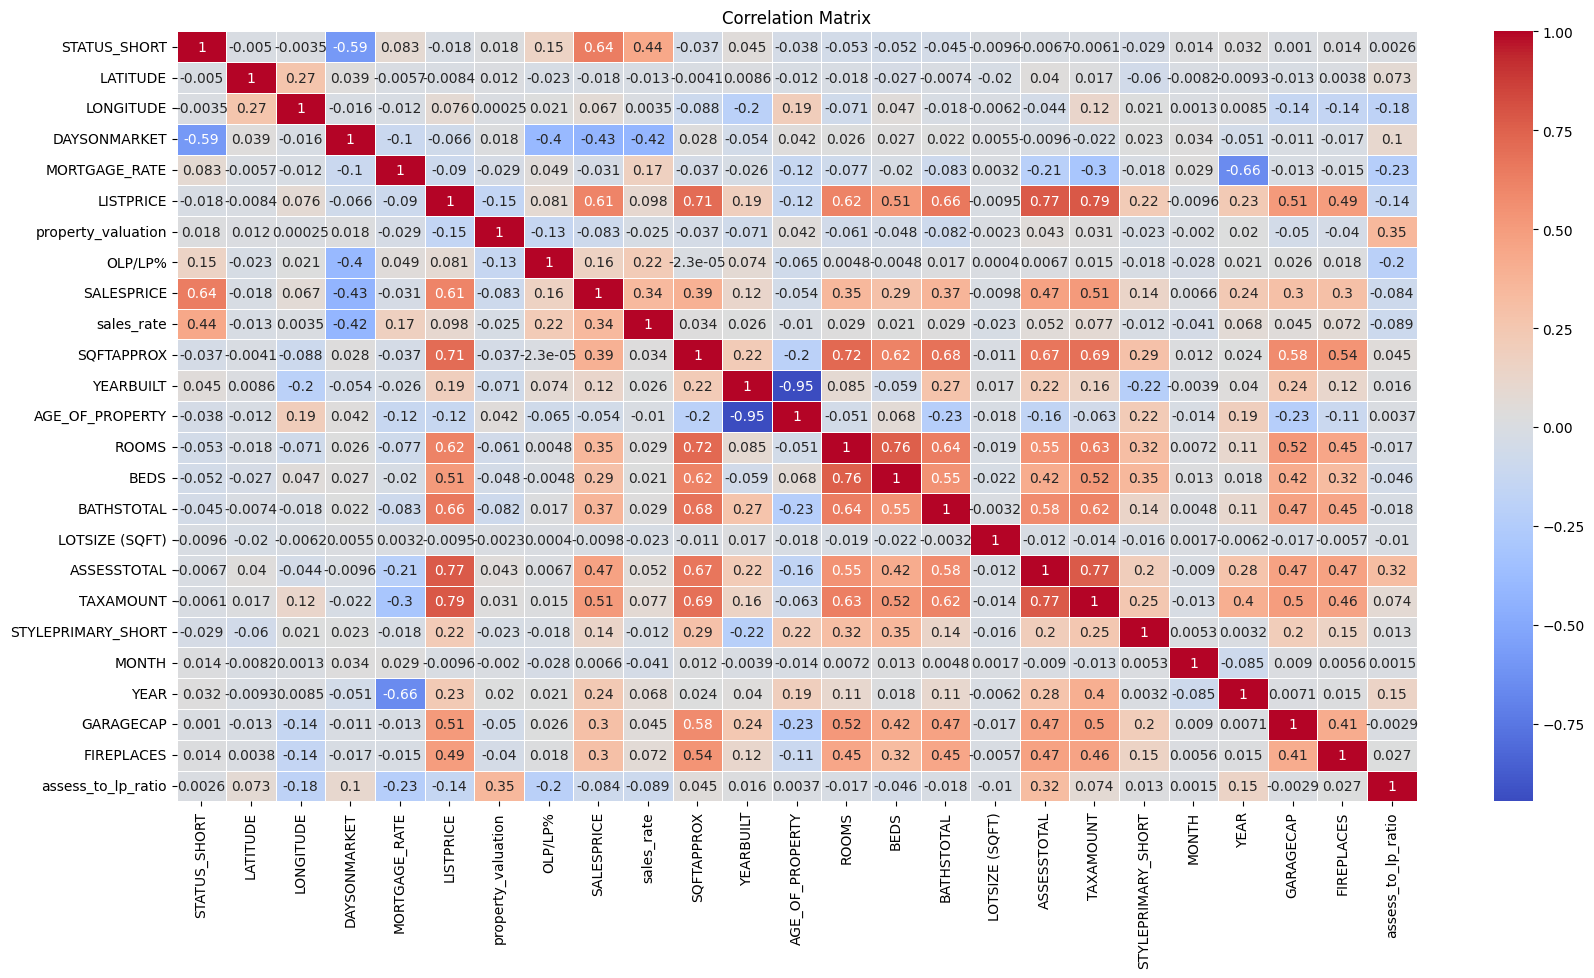

NameError: name 'save_picture' is not defined

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

temp_df = gsmls_data.copy()
temp_df['STATUS_SHORT'] = le.transform(temp_df['STATUS_SHORT'])
temp_df['STYLEPRIMARY_SHORT'] = CountEncoder(normalize=True).fit_transform(temp_df['STYLEPRIMARY_SHORT'])
fig, axs = plt.subplots(figsize=(20,10))
correlation_matrix = temp_df[[column for column in temp_df.columns if column in power_minmax_cols or column in max_abs_only_cols or column in ['SALESPRICE', 'sales_rate', 'STATUS_SHORT', 'STYLEPRIMARY_SHORT']]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidth=0.5, ax=axs)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
cols = [i for i in x_train_transformed.columns if i in ['sales_rate', 'STYLEPRIMARY_SHORT'] or i in power_minmax_cols or i in max_abs_only_cols and i not in boolean_columns]

In [ ]:
x_train_transformed, x_test_transformed, x_val_transformed = x_train_transformed[cols], x_test_transformed[cols], x_val_transformed[cols]

In [ ]:
x_train_transformed.head()

,DAYSONMARKET,BATHSTOTAL,YEARBUILT,assess_to_lp_ratio,OLP/LP%,AGE_OF_PROPERTY,LISTPRICE,ROOMS,property_valuation,LOTSIZE (SQFT),SQFTAPPROX,FIREPLACES,TAXAMOUNT,ASSESSTOTAL,MONTH,LATITUDE,YEAR,GARAGECAP,LONGITUDE,sales_rate,BEDS,MORTGAGE_RATE,STYLEPRIMARY_SHORT
0,0.009420,-0.400721,-0.439438,-0.069878,0.022135,0.217709,-0.140186,-0.168597,-0.009977,-0.038622,0.075802,0.232916,-0.286644,-0.156490,0.083333,0.961838,0.986653,0.000000,-0.921352,1.0,0.250000,0.814208,1.000000
1,0.096378,-0.341402,-0.491676,-0.061571,0.022135,0.254562,-0.199714,-0.168597,-0.009977,-0.032008,-0.047062,-0.350406,-0.372088,-0.190466,0.083333,0.961786,0.986653,0.000000,-0.921497,1.0,0.250000,0.809836,1.000000
2,0.147462,0.058666,-0.103119,0.015642,0.022135,-0.006968,-0.132390,-0.054575,-0.009977,-0.017200,0.101268,0.232916,-0.132347,-0.084923,0.083333,0.962209,0.986653,0.071429,-0.921470,1.0,0.333333,0.830601,0.245439
3,-0.092809,-0.400721,-0.321102,-0.028230,0.022135,0.137506,-0.126659,-0.054575,-0.009977,-0.028460,0.095835,0.232916,-0.185100,-0.114375,0.083333,0.961721,0.986653,0.071429,-0.921653,1.0,0.333333,0.813115,1.000000
4,0.096378,0.092649,0.113462,-0.037786,0.022135,-0.164068,0.136523,0.046897,-0.009977,0.023731,0.265116,0.232916,0.228148,0.077582,0.083333,0.962275,0.986653,0.142857,-0.921747,1.0,0.333333,0.848087,0.148612


In [ ]:
y_true_train = np.column_stack((y_train_sold, y_train_encoded))
y_true_val = np.column_stack((y_val_sold, y_val_encoded))

In [ ]:
# Create custom loss function to help evaluate the DNN better

def masked_mse_metric(y_true, y_pred, sample_weight=None):

  actual_prices = y_true[:, 0]
  sold_flags = y_true[:, 1]

  # Calculate the squared error
  square_error = tf.square(actual_prices - tf.squeeze(y_pred))

  # Apply the mask to ignore losses when properties arent sold
  masked_squared_error = square_error * sold_flags

  # Compute the mean only over the active sold samples (avoid dividing by the full batch size)
  # Add a small epsilon to avoid dividing by zero
  total_weight = tf.reduce_sum(sold_flags * (sample_weight if sample_weight is not None else 1.0)) + 1e-6
  mean_square_error = tf.reduce_sum(masked_squared_error) / total_weight

  # return masked_squared_error
  return mean_square_error


In [ ]:
def masked_mse_loss(y_true, y_pred):
    actual_prices = y_true[:, 0]
    sold_flags = tf.cast(y_true[:, 1], dtype=tf.float32)

    # Calculate the squared error
    square_error = tf.square(actual_prices - tf.squeeze(y_pred))
    masked_error = square_error * sold_flags
    return masked_error  # <== return per-sample losses

In [ ]:
def model_selector(layers, model_name='classification'):

  elif model_name == 'classification':
    return simple_classification(layers)

  elif model_name == 'regression':
    return simple_regression(layers)

In [ ]:
def simple_classification(num_layers):

  tf.random.set_seed(34)

  # Create the necessary layers

  model = keras.Sequential()
  model.add(layers.Input(shape=x_train_transformed.shape[1:]))

  for i in range(num_layers):
    # Add layers to the model
    model.add(layers.Dense(23, activation='gelu', kernel_initializer='he_normal'))

    if i == num_layers -1:
      model.add(layers.Dropout(0.7))
      model.add(layers.Dense(1, activation='sigmoid', name='classification_output'))

  optimizer = optimizer = keras.optimizers.Adamax(learning_rate=0.0012324, weight_decay=0.0010279, clipnorm=1.39)
  model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy'])

  return model

In [ ]:
def simple_regression(num_layers):

  # Current observed best: gelu, 6 layers, adamax, 1.01 gradient clipping, 0.0012 lr, 0.0031 wd

  tf.random.set_seed(34)

  # Create the necessary layers
  model = keras.Sequential()
  model.add(layers.Input(shape=x_train_transformed_new.shape[1:]))

  for i in range(num_layers):
    # Add layers to the model
    model.add(layers.Dense(24, activation='gelu', kernel_initializer='he_normal'))

    if i == num_layers -1:
      # model.add(layers.Dropout(0.3))
      model.add(layers.Dense(1, name='regression_output'))

  optimizer = optimizer = keras.optimizers.Adamax(learning_rate=0.0063905 , weight_decay=0.002884, clipnorm=1.89)
  model.compile(
        loss=masked_mse_metric,
        optimizer=optimizer,
        metrics=[masked_mse_metric])


  return model

In [ ]:
# The transformation pipeline was saved for use in other notebooks

loaded_pipeline = joblib.load(os.path.join(os.getcwd(), 'prefit_pipeline.joblib'))

In [ ]:
loaded_pipeline

FeatureUnion(transformer_list=[('power_minmax',
                                Pipeline(steps=[('select_cols',
                                                 FunctionTransformer(func=<function power_maxabs_column_selector at 0x795be97c0f40>)),
                                                ('power', PowerTransformer()),
                                                ('scale', MaxAbsScaler())])),
                               ('minmax_only',
                                Pipeline(steps=[('select_cols',
                                                 FunctionTransformer(func=<function maxabs_only_column_selector at 0x795bd43d7100>)),
                                                ('scale', MaxAbsScaler())])),
                               ('count_encoder',
                                Pipeline(steps=[('select_cols',
                                                 FunctionTransformer(func=<function count_encoder_column_selector at 0x795be97c07c0>)),
                                                ('encoder',
                                                 CountEncoder(cols=['STYLEPRIMARY_SHORT'],
                                                              combine_min_nan_groups=True,
                                                              normalize=True)),
                                                ('scale', MaxAbsScaler())]))])

In [ ]:
def make_cls_prediction(raw_data, model):

  # Prepare data to that need to be returned in the results

  support_info = raw_data[['STATUS_SHORT']]

  if 'property_valuation' not in cols:
    cols.append('property_valuation')

  # Filter out the columns not used
  target_data = raw_data[[i for i in raw_data if i in cols]]

  # Transform the data to be used in the model
  transformed_data = loaded_pipeline.transform(target_data)

  # Make the predictions
  predictions = model.predict(transformed_data)

  # Inverse transform the predictions
  prediction_status = le.inverse_transform(predictions.round(0).reshape(-1,1).astype(int))

  support_info['prediction_status'] = prediction_status
  support_info['Likelihood'] = predictions.round(3)

  conf_matrix = confusion_matrix(support_info['STATUS_SHORT'].to_numpy(), prediction_status)
  class_report = classification_report(support_info['STATUS_SHORT'].to_numpy(), prediction_status)

  return conf_matrix, class_report, support_info

# Classification & Regression Gridsearch CV

### Use the Keras Tuner object to find the best hyperperameters to train the DNNs

In [ ]:
import keras_tuner as kt

In [ ]:
# Make dynamic to return model for cls or regression

def build_model(hp, input_: tuple, batch_size: int, model_type):

  layer_dict = {}
  input_layer = layers.Input(shape=input_)
  hp.Fixed('batch_size', batch_size)

  try:

    # Step 1: Decide on if Gradient Clipping will be used
    if hp.Boolean('Gradient_Clipping') is True:
      clipnorm_value = hp.Float('clipnorm', min_value=1, max_value=2, step=0.01)
    else:
      clipnorm_value = None

    # Step 2: Set the activation choice
    activation_choice = hp.Choice(name='activation', values=['elu', 'gelu', 'swish'])

    # Step 3: Create the layers for the model
    if model_type == 'classification':

      # Tune the number of layers for classification in the model
      cls_layers = hp.Int(name='num_layers_cls', min_value=5, max_value=8)

      for idx, i in enumerate(range(cls_layers)):
        dense_layer1 = layers.Dense(
            units=hp.Int(name=f'cls_dense_layer {i}', min_value=input_[0], max_value=input_[0]),
            activation=activation_choice,
            kernel_initializer='he_normal')

        if idx == 0:
          layer_dict[f'cls_dense_layer {idx}'] = dense_layer1(input_layer)
        else:
          # Inserts the output from the previous layer as the input
          layer_dict[f'cls_dense_layer {idx}'] = dense_layer1(layer_dict[f'cls_dense_layer {idx-1}'])

        # Add dropout layers
        if idx + 1 == cls_layers:
          dropout_layer = layers.Dropout(rate=hp.Float(name='cls_dropout_rate', min_value=0.3, max_value=0.8, step=0.1))
          layer_dict[f'cls_dropout_layer {idx}'] = dropout_layer(layer_dict[f'cls_dense_layer {idx}'])

      output = layers.Dense(1, activation='sigmoid', name='classification_output')

    elif model_type == 'regression':

      # Tune the number of layers for regression in the model
      reg_layers = hp.Int(name='num_layers_reg', min_value=4, max_value=7)

      for idx, i in enumerate(range(reg_layers)):
        dense_layer2 = layers.Dense(
            units=hp.Int(name=f'reg_dense_layer {i}', min_value=input_[0], max_value=input_[0]),
            activation=activation_choice,
            kernel_initializer='he_normal'
        )

        if idx == 0:
          layer_dict[f'reg_dense_layer {idx}'] = dense_layer2(input_layer)
        else:
          layer_dict[f'reg_dense_layer {idx}'] = dense_layer2(layer_dict[f'reg_dense_layer {idx-1}'])

        # Add dropout layers
        if idx + 1 == reg_layers:
          dropout_layer = layers.Dropout(rate=hp.Float(name='reg_dropout_rate', min_value=0.0, max_value=0.5, step=0.1))
          layer_dict[f'reg_dropout_layer {idx}'] = dropout_layer(layer_dict[f'reg_dense_layer {idx}'])

      output = layers.Dense(1, name='regression_output')

    last_made_layer = list(layer_dict.keys())[-1]
    layer_dict['output'] = output(layer_dict[last_made_layer])

    # Step 4: Compile the model
    optimizer_choice = hp.Choice(name='optimizer', values=['rmsprop', 'adam', 'adamax', 'nadam', 'adamw'])
    learning_rate = hp.Float(name='learning_rate', min_value=1e-3, max_value=1e-2, sampling='log')

    if optimizer_choice == 'adam':
      optimizer = keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm_value)
    elif optimizer_choice == 'rmsprop':
      optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate, clipnorm=clipnorm_value)
    elif optimizer_choice == 'adamax':
      optimizer = keras.optimizers.Adamax(learning_rate=learning_rate, clipnorm=clipnorm_value)
    elif optimizer_choice == 'nadam':
      optimizer = keras.optimizers.Nadam(learning_rate=learning_rate, clipnorm=clipnorm_value)
    elif optimizer_choice == 'adamw':
      weight_decay = hp.Float('weight_decay', min_value=1e-4, max_value=1e-2, sampling='log')
      optimizer = keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay, clipnorm=clipnorm_value)

    model = keras.Model(inputs=input_layer, outputs=layer_dict['output'])

    # Step 5: Compile the model
    if model_type == 'classification':
      model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy'])

    elif model_type == 'regression':
      model.compile(
        loss=masked_mse_metric,
        optimizer=optimizer,
        metrics=[masked_mse_metric])

  except Exception as e:
    print(e)
    raise e

  else:
    return model

In [ ]:
base_path = '/content/drive/My Drive/Colab Notebooks/GSMLS'

best_models_dict = {
    256: {'Project_Name': 'GSMLS_SimpleCls_DNN_Tuner_256', 'Best_Model': ''},
    224: {'Project_Name': 'GSMLS_SimpleCls_DNN_Tuner_224', 'Best_Model': ''},
    192: {'Project_Name': 'GSMLS_SimpleCls_DNN_Tuner_192', 'Best_Model': ''},
    160: {'Project_Name': 'GSMLS_SimpleCls_DNN_Tuner_160', 'Best_Model': ''}
  }

model_type = 'classification'
early_stopping_cb = keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss')

for batch, proj_model in best_models_dict.items():

  random_search_tuner = kt.RandomSearch(
        hypermodel = lambda hp: build_model(hp, input_=(23,), batch_size=batch, model_type=model_type),
        objective=kt.Objective('val_loss', direction="min"),
        max_trials=50, executions_per_trial=2, directory='DNN_RandomSearch',
        project_name=proj_model['Project_Name'], seed=34, overwrite=False)

  # Step 1: Set batch size and set project name
  if os.path.exists(os.path.join(base_path, 'DNN_RandomSearch', proj_model['Project_Name'])):

    project_history = random_search_tuner.oracle.get_state()
    # random_search_tuner.oracle.get_best_trials(num_trials=1)[0].summary()
    trial_list = list(project_history['display']['trial_number'].values())

    try:

      if trial_list[-1] == 50:
        print(f"{proj_model['Project_Name']} has finished tuning. Moving to next configuration")
        best_models_dict[batch]['Best_Model'] = random_search_tuner.get_best_hyperparameters()[0].values
        continue
      else:
        print(f"{proj_model['Project_Name']} has not finished tuning. Continuing from {trial_list[-1] + 1}")

    except IndexError:
      pass

  # Step 2: Initiate RandomSearch function
  if model_type == 'classification':
    random_search_tuner.search(x_train_transformed, y_train_encoded,
                               epochs=50, batch_size=batch, sample_weight=sample_weights,
                               validation_data=(x_val_transformed, y_val_encoded), verbose=1,
                               callbacks=[early_stopping_cb])

  elif model_type == 'regression':
    random_search_tuner.search(x_train_transformed, y_true_train,
                               epochs=50, batch_size=batch,
                               validation_data=(x_val_transformed, y_true_val), verbose=1,
                               callbacks=[early_stopping_cb])

  if best_models_dict[160]['Best_Model'] != '':
    print('DNN Grid Search Completed')

Trial 34 Complete [00h 05m 17s]
val_loss: 0.13161851465702057

Best val_loss So Far: 0.11944140121340752
Total elapsed time: 04h 07m 43s

Search: Running Trial #35

Value             |Best Value So Far |Hyperparameter
224               |224               |batch_size
False             |True              |Gradient_Clipping
gelu              |gelu              |activation
5                 |7                 |num_layers_cls
23                |23                |cls_dense_layer 0
23                |23                |cls_dense_layer 1
23                |23                |cls_dense_layer 2
23                |23                |cls_dense_layer 3
23                |23                |cls_dense_layer 4
0.6               |0.7               |cls_dropout_rate
adamax            |adamax            |optimizer
0.0034965         |0.0063905         |learning_rate
1.82              |1.89              |clipnorm
23                |23                |cls_dense_layer 5
23                |23                

In [ ]:
target_cols = {'batch_size': [], 'Gradient_Clipping':[], 'clipnorm':[],
               'activation': [], 'cls_dense_layer 0': [],
               'cls_dropout_rate': [], 'learning_rate': [], 'num_layers_cls': [],
               'optimizer': [], 'weight_decay': [], 'best_score': []}

score_list = [0.10749303176999092, 0.1065344363451004,
              0.10660234093666077, 0.10483133047819138]

for key, value in zip(best_models_dict.keys(), score_list):
  for i in target_cols.keys():
    if i == 'batch_size':
      target_cols[i].append(key)
    elif i == 'best_score':
      target_cols[i].append(round(value, 5))
    else:
      target_cols[i].append(best_models_dict[key]['Best_Model'][i])

In [ ]:
best_models_df = pd.DataFrame(target_cols)

In [ ]:
best_models_df.sort_values(by='best_score', ascending=True)

,batch_size,Gradient_Clipping,clipnorm,activation,cls_dense_layer 0,cls_dropout_rate,learning_rate,num_layers_cls,optimizer,weight_decay,best_score
3,160,False,1.82,gelu,23,0.3,0.003497,5,adamax,0.000290,0.10483
1,224,True,1.13,gelu,23,0.3,0.001471,8,adam,0.000215,0.10653
2,192,True,1.27,gelu,23,0.4,0.001184,6,adam,0.000551,0.10660
0,256,True,1.99,elu,23,0.0,0.001336,7,adamw,0.005045,0.10749


In [ ]:
# Evaluate the simple classification dnn first
simple_model = model_selector(7, 'classification')

In [ ]:
simple_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 23)             │           552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │           552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │           552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │           552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 23)             │           552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │           552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 23)             │           552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 1)              │            24 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,888 (15.19 KB)

 Trainable params: 3,888 (15.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Simple Deep Neural Network
# Allow for early stopping and create model checkpoints
checkpoint_cb = keras.callbacks.ModelCheckpoint('GSMLS_SimpleCls_DNN_Best_Sample_FullData.keras', save_best_only=True, monitor='val_loss')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss')

history = simple_model.fit(x_train_transformed, y_train_encoded,
                    epochs=50, batch_size=224,
                    validation_data=(x_val_transformed, y_val_encoded), verbose=1,
                    sample_weight=sample_weights,
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/50
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 220s 82ms/step - accuracy: 0.7901 - loss: 0.4530 - val_accuracy: 0.9476 - val_loss: 0.1376
Epoch 2/50
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 191s 80ms/step - accuracy: 0.8240 - loss: 0.3905 - val_accuracy: 0.9447 - val_loss: 0.1416
Epoch 3/50
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 198s 83ms/step - accuracy: 0.8254 - loss: 0.3841 - val_accuracy: 0.9399 - val_loss: 0.1465
Epoch 4/50
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 195s 82ms/step - accuracy: 0.8273 - loss: 0.3794 - val_accuracy: 0.9412 - val_loss: 0.1432
Epoch 5/50
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 200s 83ms/step - accuracy: 0.8290 - loss: 0.3754 - val_accuracy: 0.9392 - val_loss: 0.1446
Epoch 6/50
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 195s 81ms/step - accuracy: 0.8304 - loss: 0.3725 - val_accuracy: 0.9388 - val_loss: 0.1429
Epoch 7/50
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 193s 81ms/step - accuracy: 0.8310 - loss: 0.3703 - val_accuracy: 0.9386 - val_loss: 0.1415
Epoch 8/50
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 191s 80ms/step - accuracy: 

In [ ]:
conf_matrix, class_report, results = make_cls_prediction(cleaned_data.sample(2000), simple_model)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


In [ ]:
results.head(20)

,STATUS_SHORT,prediction_status,Likelihood
55347,SD,SD,0.741
381599,SD,EXP,0.421
548528,SD,SD,0.992
139643,SD,SD,0.588
425987,SD,SD,0.966
59081,EXP,EXP,0.128
216352,SD,SD,0.978
242553,SD,EXP,0.060
268215,EXP,EXP,0.078
474939,SD,SD,0.997


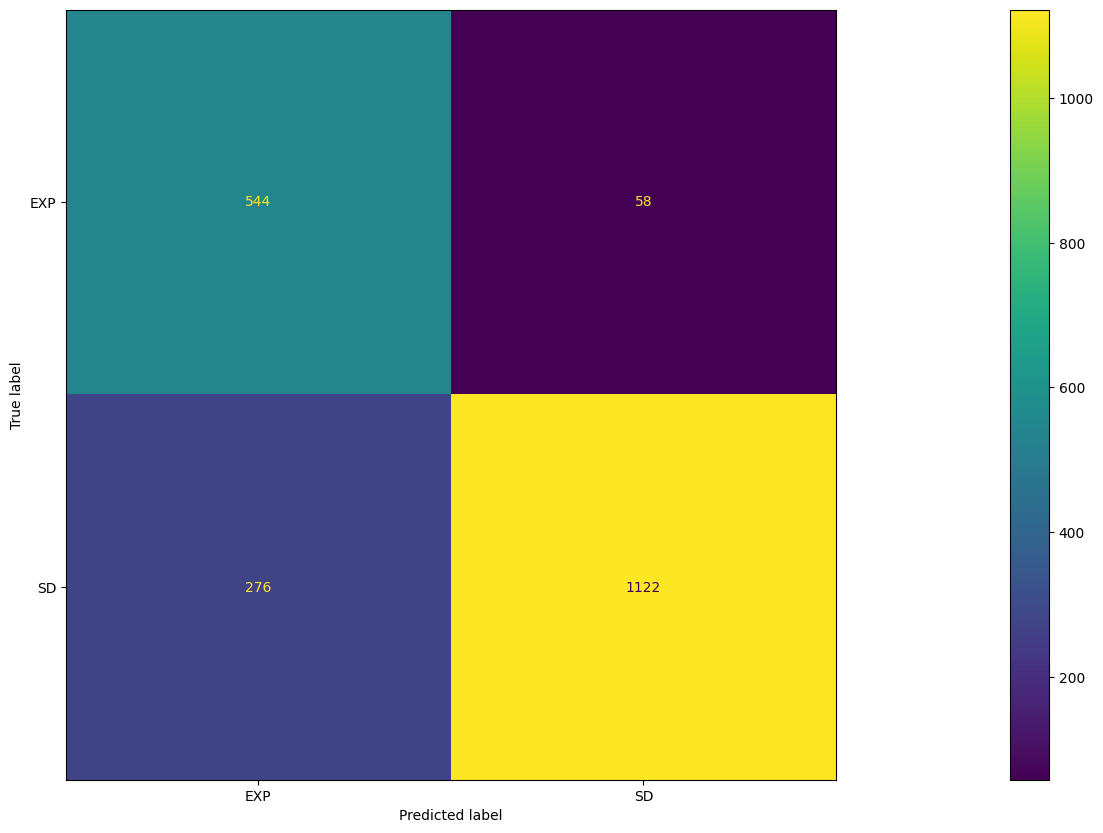

In [ ]:
fig, axs = plt.subplots(figsize=(45,10))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['EXP', 'SD'])
disp.plot(ax=axs)
plt.show()

In [ ]:
print(class_report)

              precision    recall  f1-score   support

         EXP       0.66      0.90      0.77       602
          SD       0.95      0.80      0.87      1398

    accuracy                           0.83      2000
   macro avg       0.81      0.85      0.82      2000
weighted avg       0.86      0.83      0.84      2000



In [ ]:
simple_model.save('GSMLS_SimpleCls_DNN.keras')

# Simple Regression Gridsearch CV

In [ ]:
def make_reg_prediction(raw_data, model):

  results_dict = {
      'r2_score': 0.0,
      'mean_absolute_error': 0.0,
      'root_mean_squared_error': 0.0,
      'mean_absolute_percentage_error': 0.0,
  }

  # Prepare data to that need to be returned in the results
  support_info = raw_data[['YEAR', 'property_valuation', 'SALESPRICE', 'STATUS_SHORT']]

  if 'property_valuation' not in cols:
    cols.append('property_valuation')

  # Filter out the columns not used
  target_data = raw_data[[i for i in raw_data if i in cols]]

  # # Transform the data to be used in the model
  transformed_data = loaded_pipeline.transform(target_data)
  status_encoded = le.transform(support_info['STATUS_SHORT'])
  full_transformed_data = np.column_stack((transformed_data, status_encoded))

  # Make the predictions
  predictions = model.predict(full_transformed_data)

  # Inverse transform the predictions
  predicted_price = target_transformer.inverse_transform(predictions.reshape(-1,1))
  support_info['PREDICTED_PRICE'] = predicted_price
  print(support_info['PREDICTED_PRICE'].tail())
  print(support_info['SALESPRICE'].tail())
  target_ground_truth = support_info[support_info['STATUS_SHORT'] == 'SD']['SALESPRICE']
  target_predicted = support_info[support_info['STATUS_SHORT'] == 'SD']['PREDICTED_PRICE']

  results_dict['r2_score'] = r2_score(target_ground_truth, target_predicted)
  results_dict['mean_absolute_error'] = mean_absolute_error(target_ground_truth, target_predicted)
  results_dict['root_mean_squared_error'] = root_mean_squared_error(target_ground_truth, target_predicted)
  results_dict['mean_absolute_percentage_error'] = mean_absolute_percentage_error(target_ground_truth, target_predicted)
  # conf_matrix = confusion_matrix(support_info['STATUS_SHORT'], prediction_status)
  # class_report = classification_report(support_info['STATUS_SHORT'], prediction_status)

  return pd.Series(results_dict), support_info

In [ ]:
print(x_train_transformed.shape)
print(y_train_encoded.shape)
print(x_val_transformed.shape)
print(y_val_encoded.shape)

(536317, 23)
(536317,)
(13600, 23)
(13600,)


In [ ]:
# Merge the sold encoded data to use in the regression training
x_train_transformed_new = np.column_stack((x_train_transformed, y_train_encoded))
x_val_transformed_new = np.column_stack((x_val_transformed, y_val_encoded))

In [ ]:
print(x_train_transformed_new.shape)
print(x_val_transformed_new.shape)

(536317, 24)
(13600, 24)


In [ ]:
base_path = '/content/drive/My Drive/Colab Notebooks/GSMLS'

best_models_dict = {
    256: {'Project_Name': 'GSMLS_SimpleReg_DNN_Tuner_256', 'Best_Model': ''},
    224: {'Project_Name': 'GSMLS_SimpleReg_DNN_Tuner_224', 'Best_Model': ''},
    192: {'Project_Name': 'GSMLS_SimpleReg_DNN_Tuner_192', 'Best_Model': ''},
    160: {'Project_Name': 'GSMLS_SimpleReg_DNN_Tuner_160', 'Best_Model': ''}
  }

model_type = 'regression'
early_stopping_cb = keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss')

for batch, proj_model in best_models_dict.items():

  random_search_tuner = kt.RandomSearch(
        hypermodel = lambda hp: build_model(hp, input_=(24,), batch_size=batch, model_type=model_type),
        objective=kt.Objective('val_loss', direction="min"),
        max_trials=50, executions_per_trial=2, directory='DNN_RandomSearch',
        project_name=proj_model['Project_Name'], seed=34, overwrite=False)

  # Step 1: Set batch size and set project name
  if os.path.exists(os.path.join(base_path, 'DNN_RandomSearch', proj_model['Project_Name'])):

    project_history = random_search_tuner.oracle.get_state()
    # random_search_tuner.oracle.get_best_trials(num_trials=1)[0].summary()
    trial_list = list(project_history['display']['trial_number'].values())

    try:

      if trial_list[-1] == 50:
        print(f"{proj_model['Project_Name']} has finished tuning. Moving to next configuration")
        best_models_dict[batch]['Best_Model'] = random_search_tuner.get_best_hyperparameters()[0].values
        continue
      else:
        print(f"{proj_model['Project_Name']} has not finished tuning. Continuing from {trial_list[-1] + 1}")

    except IndexError:
      pass

  # Step 2: Initiate RandomSearch function
  if model_type == 'classification':
    random_search_tuner.search(x_train_transformed, y_train_encoded,
                               epochs=50, batch_size=batch, sample_weight=sample_weights,
                               validation_data=(x_val_transformed, y_val_encoded), verbose=1,
                               callbacks=[early_stopping_cb])

  elif model_type == 'regression':
    random_search_tuner.search(x_train_transformed_new, y_true_train,
                               epochs=50, batch_size=batch,
                               validation_data=(x_val_transformed_new, y_true_val), verbose=1,
                               callbacks=[early_stopping_cb])

  if best_models_dict[160]['Best_Model'] != '':
    print('DNN Grid Search Completed')

Trial 44 Complete [00h 05m 45s]
val_loss: 0.00039509820635430515

Best val_loss So Far: 0.0002964565792353824
Total elapsed time: 06h 06m 32s

Search: Running Trial #45

Value             |Best Value So Far |Hyperparameter
224               |224               |batch_size
True              |True              |Gradient_Clipping
gelu              |gelu              |activation
5                 |6                 |num_layers_reg
24                |24                |reg_dense_layer 0
24                |24                |reg_dense_layer 1
24                |24                |reg_dense_layer 2
24                |24                |reg_dense_layer 3
0.4               |0                 |reg_dropout_rate
rmsprop           |adamax            |optimizer
0.0037568         |0.0012455         |learning_rate
1.22              |1.01              |clipnorm
24                |24                |reg_dense_layer 4
24                |24                |reg_dense_layer 5
0.00041489        |0.0030983    

In [ ]:
# Do 100 epochs for the best regression hyperparams. The search hit a max of 50 epochs and still could have gotten better
# Retrain regression models with no dropout next round
# Observed best: gelu, 6 layers, adamax, 1.01 gradient clipping, 0.0012 lr, 0.0031 wd
# gelu, 5, adamax, 0.1 dropout, no grad clip, 0.0025 lr, 0.0052 wd (try 2 grad clip?)

In [ ]:
simple_model = model_selector(6, 'regression')

In [ ]:
simple_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regression_output (Dense)       │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,625 (14.16 KB)

 Trainable params: 3,625 (14.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('GSMLS_SimpleReg_DNN_Best_Sample_FullData.keras', save_best_only=True, monitor='val_loss')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss')

history = simple_model.fit(x_train_transformed_new, y_true_train,
                    epochs=100, batch_size=224,
                    validation_data=(x_val_transformed_new, y_true_val), verbose=1,
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 215s 82ms/step - loss: 0.0037 - masked_mse_metric: 0.0037 - val_loss: 3.6056e-04 - val_masked_mse_metric: 3.6086e-04
Epoch 2/100
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 199s 83ms/step - loss: 1.7177e-04 - masked_mse_metric: 1.7177e-04 - val_loss: 3.7403e-04 - val_masked_mse_metric: 3.7441e-04
Epoch 3/100
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 194s 81ms/step - loss: 1.7318e-04 - masked_mse_metric: 1.7318e-04 - val_loss: 3.4220e-04 - val_masked_mse_metric: 3.4266e-04
Epoch 4/100
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 194s 81ms/step - loss: 1.6689e-04 - masked_mse_metric: 1.6689e-04 - val_loss: 3.5357e-04 - val_masked_mse_metric: 3.5406e-04
Epoch 5/100
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 196s 82ms/step - loss: 1.6387e-04 - masked_mse_metric: 1.6387e-04 - val_loss: 3.1587e-04 - val_masked_mse_metric: 3.1645e-04
Epoch 6/100
2395/2395 ━━━━━━━━━━━━━━━━━━━━ 193s 81ms/step - loss: 1.6351e-04 - masked_mse_metric: 1.6351e-04 - val_loss: 3.1315e-04 - val_masked_mse_metric: 3.1377e-04


In [ ]:
reg_results, results_df = make_reg_prediction(cleaned_data[(cleaned_data['YEAR'] == 2025)], simple_model)

169/169 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step
555705    2.503652e+05
555706    4.808786e+05
555707    7.874194e+05
555708    9.998953e+05
555709    1.215795e+06
Name: PREDICTED_PRICE, dtype: float32
555705     255000.0
555706     480000.0
555707     800000.0
555708    1100000.0
555709    1200000.0
Name: SALESPRICE, dtype: float64


##Initial Results
###R2 Score - Excellent
###MAE - Take as the percentage of the avg home price to evaluate. Between 5-10% is good
###RMSE - Needs work, almost double MSE which means there are large outliers
###MAPE - 41% Not Good. Very large prediction losses. Between 5-20% is good

## Post Outlier Removal Results

###R2 Score - Excellent
###MAE - Take as the percentage of the avg home price to evaluate. Between 5-10% is good
###RMSE - Needs work, almost double MSE which means there are large outliers
###MAPE - 5.1% - Excellent. Between 5-20% is good

In [ ]:
reg_results

,0
r2_score,0.968085
mean_absolute_error,39434.810995
root_mean_squared_error,70555.216648
mean_absolute_percentage_error,0.052706


In [ ]:
simple_model.save('GSMLS_SimpleReg_DNN.keras')

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
results_df['MAPE'] = round((abs(results_df['SALESPRICE'] - results_df['PREDICTED_PRICE']) / results_df['SALESPRICE']) * 100, 3)

In [ ]:
high_mape = results_df[(results_df['MAPE'] >= 20) & (results_df['STATUS_SHORT'] == 'SD')]

In [ ]:
high_mape.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96 entries, 550340 to 555614
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   YEAR                96 non-null     int64  
 1   property_valuation  96 non-null     int64  
 2   SALESPRICE          96 non-null     float64
 3   STATUS_SHORT        96 non-null     object 
 4   PREDICTED_PRICE     96 non-null     float32
 5   MAPE                96 non-null     float64
dtypes: float32(1), float64(2), int64(2), object(1)
memory usage: 4.9+ KB


In [ ]:
high_mape.describe()

,YEAR,property_valuation,SALESPRICE,PREDICTED_PRICE,MAPE
count,96.0,96.000000,9.600000e+01,9.600000e+01,96.000000
mean,2025.0,0.083333,8.571077e+05,8.138639e+05,28.302594
std,0.0,0.427149,7.120827e+05,5.416963e+05,8.447663
min,2025.0,-1.000000,1.150000e+05,1.429492e+05,20.033000
25%,2025.0,0.000000,3.037500e+05,3.496329e+05,22.410250
50%,2025.0,0.000000,6.530000e+05,7.108408e+05,25.237000
75%,2025.0,0.000000,1.231325e+06,1.057940e+06,31.374000
max,2025.0,1.000000,3.400000e+06,2.330306e+06,63.266000


In [ ]:
high_mape.sort_values(by='MAPE', ascending=False)

,YEAR,property_valuation,SALESPRICE,STATUS_SHORT,PREDICTED_PRICE,MAPE
551606,2025,0,475000.0,SD,7.755122e+05,63.266
554794,2025,0,180000.0,SD,2.781583e+05,54.532
554131,2025,0,211282.0,SD,3.222942e+05,52.542
554666,2025,1,947299.0,SD,1.436988e+06,51.693
550403,2025,1,215000.0,SD,3.186498e+05,48.209
551067,2025,0,3400000.0,SD,1.904157e+06,43.995
554522,2025,0,120000.0,SD,1.721775e+05,43.481
550344,2025,1,175000.0,SD,2.463342e+05,40.762
552736,2025,0,350000.0,SD,4.906604e+05,40.189
550481,2025,0,515000.0,SD,7.170266e+05,39.228
